In [1]:
pip install datasets torchmetrics

In [3]:
from google.colab import files
import os
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import albumentations as A

import torch
import torchmetrics


from transformers import AutoModelForImageClassification, AutoProcessor, AdamW, TrainingArguments, Trainer
from datasets import Dataset as HFDataset, Image


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.2 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Data Loading

In [4]:
uploaded = files.upload()

KeyboardInterrupt: 

In [9]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/

In [10]:
! chmod 600 /root/.kaggle/kaggle.json

In [11]:
!kaggle competitions download -c open-cv-py-torch-project-2-classification-round-2

100% 1.29G/1.29G [01:08<00:00, 21.1MB/s]
100% 1.29G/1.29G [01:08<00:00, 20.3MB/s]


In [12]:
!unzip open-cv-py-torch-project-2-classification-round-2.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: images/images/16273186685497510505.jpg  
  inflating: images/images/16282614765807136033.jpg  
  inflating: images/images/16284339368408617325.jpg  
  inflating: images/images/16291671383938929277.jpg  
  inflating: images/images/16292068910159576399.jpg  
  inflating: images/images/16296225045024370393.jpg  
  inflating: images/images/16299062930688223105.jpg  
  inflating: images/images/16299107618575423489.jpg  
  inflating: images/images/16303389888524426910.jpg  
  inflating: images/images/16304405155635632552.jpg  
  inflating: images/images/1630480295804231927.jpg  
  inflating: images/images/16305353331382847428.jpg  
  inflating: images/images/16310534578938153796.jpg  
  inflating: images/images/16316726223246099607.jpg  
  inflating: images/images/16321027829450957963.jpg  
  inflating: images/images/16321308496809088759.jpg  
  inflating: images/images/16321361765090322346.jpg  
  inflating: im

# Settings

In [5]:
image_dir = 'images/images/'
model_name = "nateraw/food"

BATCH_SIZE = 16
LR1 = 0.001
LR2 = 2e-5
EPOCH1 = 10
EPOCH2 = 5

Let's take a transformer pretrained on food from Google. The first training cycle will include only the classifier and will last for 10 epochs. The second training cycle will be full and will include 5 epochs.

# Data Analyz

In [6]:
train = pd.read_csv('train.csv')
train.head(20)

,id,class
0,14278962987112149800,githeri
1,13190220095752321996,ugali
2,10431803432626641638,kachumbari
3,4222441716327528413,githeri
4,2547906925836120627,matoke
5,3039963436498421762,sukumawiki
6,7183513324664960560,bhaji
7,16470167078556534164,mandazi
8,2423183276356979620,kukuchoma
9,3375255202666977472,bhaji


In [7]:
test = pd.read_csv('test.csv')
test.head(4)

,id
0,9156739011499789258
1,2049465964503133373
2,6446998501027132988
3,4194396063119815321


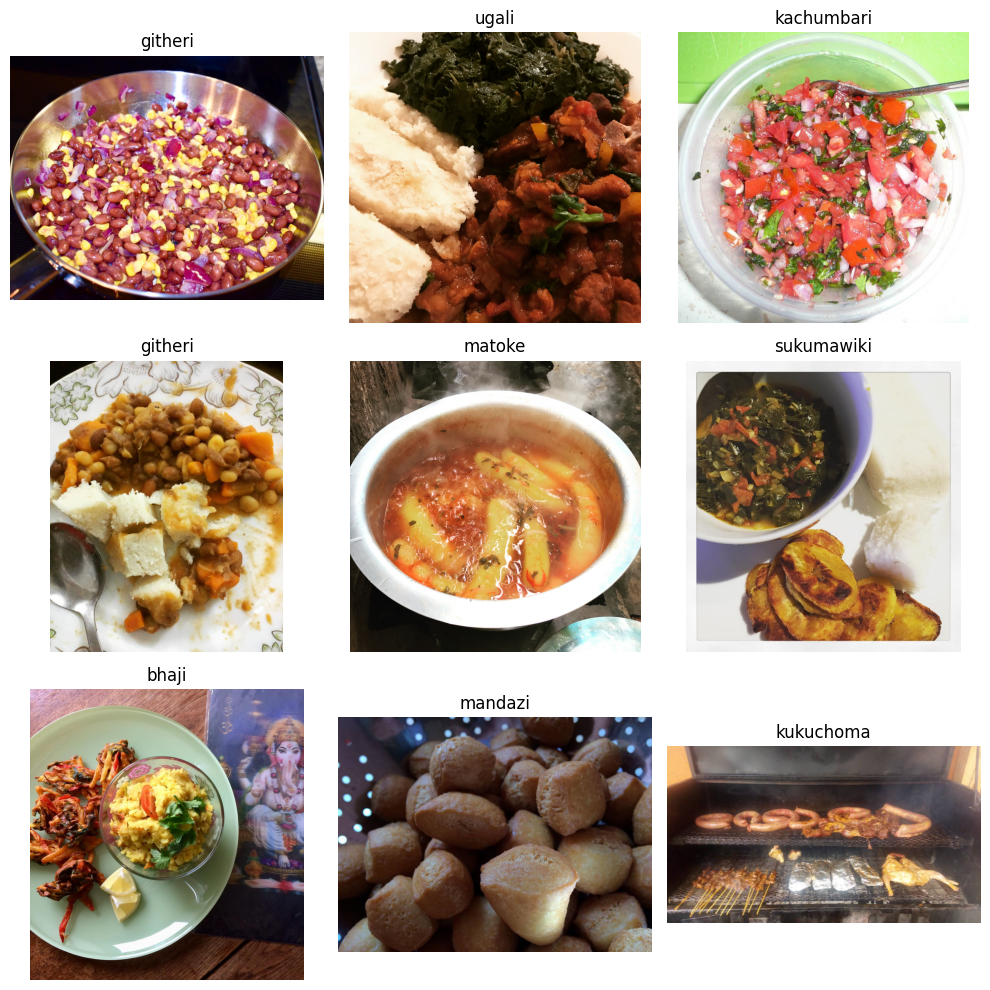

In [8]:
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(rows):
    for j in range(cols):
        idx = i * cols + j
        if idx < len(train):
            image_id = train.iloc[idx]['id']
            image_path = f'images/images/{image_id}.jpg'
            img = mpimg.imread(image_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(train.iloc[idx]['class'])
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [9]:
train['class'].value_counts(normalize=True)*100

,proportion
class,
chapati,13.188494
nyamachoma,11.995104
bhaji,9.669523
ugali,9.608323
mandazi,9.485924
kachumbari,7.558140
matoke,7.389841
githeri,7.328641
masalachips,6.701346


We see a slight imbalance in the data, but it's not too significant. To increase the amount of data, we will perform augmentation.

# Data Preparation

In [10]:
train_df, val_df = train_test_split(train, test_size=0.2, stratify=train['class'], random_state=42)

In [11]:
val_df['class'].value_counts()

,count
class,
chapati,172
nyamachoma,157
bhaji,126
ugali,126
mandazi,124
kachumbari,99
matoke,97
githeri,96
masalachips,88


In [12]:
unique_classes = train['class'].unique()
class_to_id = {cls: i for i,cls in enumerate(unique_classes)}
id_to_class = {i: cls for cls, i in class_to_id.items()}
class_to_id

{'githeri': 0,
 'ugali': 1,
 'kachumbari': 2,
 'matoke': 3,
 'sukumawiki': 4,
 'bhaji': 5,
 'mandazi': 6,
 'kukuchoma': 7,
 'nyamachoma': 8,
 'pilau': 9,
 'chapati': 10,
 'masalachips': 11,
 'mukimo': 12}

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
augmentation = A.Compose([
    A.RandomRotate90(p=0.1),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, border_mode=0),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=10, val_shift_limit=10, p=0.4)
])

In [15]:
processor = AutoProcessor.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [16]:
class TDataset(Dataset):
    def __init__(self, df, transform=None, processor=processor, image_dir=image_dir, train=False):
        self.data = df
        self.image_dir = image_dir
        self.transform = transform
        self.train = train
        self.processor=processor


    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.image_dir, f'{self.data.iloc[idx]["id"]}.jpg')  # Путь к изображению
        image = cv2.imread(img_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        encoding = self.processor(image, return_tensors='pt')
        pixel_values = encoding['pixel_values'].squeeze(0)

        if self.train:
          label = class_to_id[self.data.iloc[idx]['class']]
          return {'pixel_values': pixel_values, 'labels': torch.tensor(label, dtype=torch.long)}
        else:
          return {'pixel_values': pixel_values}


In [17]:
train_dataset = TDataset(df=train_df, transform=augmentation, train=True)
val_dataset = TDataset(df=val_df, train=True)
test_dataset = TDataset(df=test)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Modeling

In [19]:
model = AutoModelForImageClassification.from_pretrained(model_name, num_labels=len(unique_classes), ignore_mismatched_sizes=True,
                                                        id2label=id_to_class, label2id=class_to_id)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at nateraw/food and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([101, 768]) in the checkpoint and torch.Size([13, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([101]) in the checkpoint and torch.Size([13]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
for param in model.base_model.parameters():
  param.requires_grad = False

In [27]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter name: {name}, requires grad: {param.requires_grad}, shape: {param.shape}")

Parameter name: classifier.weight, requires grad: True, shape: torch.Size([13, 768])
Parameter name: classifier.bias, requires grad: True, shape: torch.Size([13])


In [28]:
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=len(unique_classes)).to(device)

In [29]:
def compute_acc(pred):
  logits, labels = pred
  preds = torch.tensor(logits).argmax(-1).to(device)
  labels = torch.tensor(labels).to(device)

  acc = accuracy(preds, labels).item()
  return {'accuracy': acc}

In [30]:
training_args = TrainingArguments(
    output_dir='./results_first',
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    learning_rate = LR1,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    num_train_epochs = EPOCH1,
    weight_decay = 0.01,
    logging_dir = './logs',
    logging_steps = 10,
    save_total_limit = 2,
    remove_unused_columns = False,
    load_best_model_at_end = True,
    report_to = 'none'
)

In [31]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    compute_metrics = compute_acc
)

In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.168900,1.120975,0.642202
2,0.968600,1.049687,0.658257
3,1.030500,0.999635,0.672783
4,1.008800,0.975202,0.681957
5,0.980100,0.956365,0.686544
6,0.824200,0.941825,0.690367
7,0.783300,0.931000,0.693425
8,0.904100,0.928378,0.699541
9,0.734700,0.926243,0.698777
10,0.709700,0.924464,0.699541


TrainOutput(global_step=3270, training_loss=0.9557007823150822, metrics={'train_runtime': 2545.9668, 'train_samples_per_second': 20.534, 'train_steps_per_second': 1.284, 'total_flos': 4.051680630924165e+18, 'train_loss': 0.9557007823150822, 'epoch': 10.0})

In [33]:
for param in model.base_model.parameters():
  param.requires_grad = True

In [41]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter name: {name}, requires grad: {param.requires_grad}, shape: {param.shape}")

Parameter name: vit.embeddings.cls_token, requires grad: True, shape: torch.Size([1, 1, 768])
Parameter name: vit.embeddings.position_embeddings, requires grad: True, shape: torch.Size([1, 197, 768])
Parameter name: vit.embeddings.patch_embeddings.projection.weight, requires grad: True, shape: torch.Size([768, 3, 16, 16])
Parameter name: vit.embeddings.patch_embeddings.projection.bias, requires grad: True, shape: torch.Size([768])
Parameter name: vit.encoder.layer.0.attention.attention.query.weight, requires grad: True, shape: torch.Size([768, 768])
Parameter name: vit.encoder.layer.0.attention.attention.query.bias, requires grad: True, shape: torch.Size([768])
Parameter name: vit.encoder.layer.0.attention.attention.key.weight, requires grad: True, shape: torch.Size([768, 768])
Parameter name: vit.encoder.layer.0.attention.attention.key.bias, requires grad: True, shape: torch.Size([768])
Parameter name: vit.encoder.layer.0.attention.attention.value.weight, requires grad: True, shape: t

In [42]:
training_args.learning_rate = LR2
training_args.num_train_epochs = EPOCHS2

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    compute_metrics = compute_acc
)

In [43]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.603800,0.676860,0.764526
2,0.377900,0.646813,0.774465
3,0.382400,0.615805,0.791284
4,0.304500,0.607386,0.795872
5,0.274900,0.601585,0.798930


TrainOutput(global_step=1635, training_loss=0.3963426867027166, metrics={'train_runtime': 1940.1056, 'train_samples_per_second': 13.473, 'train_steps_per_second': 0.843, 'total_flos': 2.0258403154620826e+18, 'train_loss': 0.3963426867027166, 'epoch': 5.0})

Our goal was to achieve an accuracy greater than 70. This has been met on the validation data! Let's take a look at the test results.

# Evaluating

In [48]:
model.eval()
predictions = []

for batch in test_loader:
  inputs = {k: v.to(device) for k, v in batch.items()}
  with torch.inference_mode():
    outputs = model(**inputs).logits
  batch_preds = torch.argmax(outputs, dim=-1).cpu().numpy()
  predictions.extend(batch_preds)

test['class'] = [id_to_class[idx] for idx in predictions]
test.head(10)

,id,class
0,9156739011499789258,nyamachoma
1,2049465964503133373,kachumbari
2,6446998501027132988,nyamachoma
3,4194396063119815321,ugali
4,9018117998187006009,ugali
5,6246759883907852128,masalachips
6,16478122708528316044,nyamachoma
7,14045745760440690312,chapati
8,7872954221890963019,matoke
9,4868486697531317477,chapati


In [49]:
test.to_csv('submission.csv', index=False)

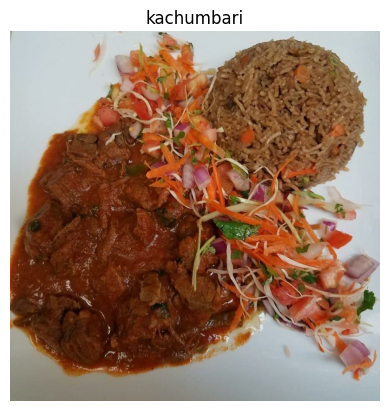

In [52]:
image_id = test.iloc[1]['id']
image_path = f'images/images/{image_id}.jpg'

img = mpimg.imread(image_path)
plt.imshow(img)
plt.title(test.iloc[1]['class'] )
plt.axis('off')
plt.show()